# Fractal SNN Packet Demo / Демонстрация SNN-пакета с фрактальной полезной нагрузкой

**RU.** Этот notebook показывает, как фрактальное число превращается в самосинхронизирующийся SNN-пакет. В предыдущем notebook мы разобрали само число: `digits -> (P_i, S_i) -> C_i(t) -> A(t) -> decoding`. Здесь добавляем транспортный слой: служебные поля, синхронизацию, знак, число разрядов, guard-интервалы, checksum и восстановление пакета на стороне приемника.

Путь данных:

```text
signed number -> packet envelope -> fractal payload A(t) -> receiver sync -> payload decoding -> checksum -> signed number
```

Notebook отвечает на четыре вопроса:

1. **Зачем нужен packet envelope?** Он дает приемнику точку синхронизации, знак числа, длину mixed-radix payload и границы полезной нагрузки.
2. **Что именно передается во fractal payload?** Не двоичная строка, а суммарный амплитудный сигнал каналов, выбранных ячейками фрактального алфавита.
3. **Как приемник восстанавливает число?** Он находит `PREAMBLE + START_DELIMITER`, читает service fields, выделяет payload и запускает fractal decoder.
4. **Как обнаруживаются ошибки?** Packet проверяет weighted checksum по mixed-radix digits `V_i`.

**EN.** This notebook shows how a fractal number becomes a self-synchronizing SNN packet. The previous notebook focused on the number itself: `digits -> (P_i, S_i) -> C_i(t) -> A(t) -> decoding`. Here we add the transport layer: service fields, synchronization, sign, digit count, guard intervals, checksum, and receiver-side packet recovery.

Data path:

```text
signed number -> packet envelope -> fractal payload A(t) -> receiver sync -> payload decoding -> checksum -> signed number
```

The notebook answers four questions:

1. **Why do we need a packet envelope?** It gives the receiver a synchronization point, sign, mixed-radix payload length, and payload boundaries.
2. **What is transmitted inside the fractal payload?** Not a binary string, but a summed amplitude signal generated by selected fractal-alphabet cells.
3. **How does the receiver recover the number?** It finds `PREAMBLE + START_DELIMITER`, reads service fields, extracts the payload, and runs the fractal decoder.
4. **How are errors detected?** The packet validates a weighted checksum over mixed-radix digits `V_i`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "experiments" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from snn_framework import FractalSNNPacketCodec, MatrixCell, MatrixFractalNumber

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 120)

SERVICE_COLORS = {
    "PREAMBLE": "#DBEAFE",
    "START_DELIMITER": "#BFDBFE",
    "SIGN": "#E5E7EB",
    "DIGIT_COUNT": "#E5E7EB",
    "PAYLOAD_START_GUARD": "#F3F4F6",
    "FRACTAL_PAYLOAD": "#FED7AA",
    "END_GUARD": "#F3F4F6",
    "END_DELIMITER": "#BFDBFE",
    "CHECK": "#DCFCE7",
}


def bits_to_string(bits):
    return "".join(str(int(bit)) for bit in bits)


def field_table(encoded) -> pd.DataFrame:
    rows = []
    for field in encoded.fields:
        rows.append({
            "field": field.name,
            "start_tick": field.start_tick,
            "end_tick": field.end_tick,
            "duration_ticks": field.end_tick - field.start_tick,
            "pattern_or_signal": bits_to_string(field.pattern) if field.pattern is not None else "A(t), fractal amplitude signal",
            "role": field.description,
        })
    return pd.DataFrame(rows)


def payload_cell_table(model: MatrixFractalNumber, cells: tuple[MatrixCell, ...]) -> pd.DataFrame:
    rows = []
    for cell in cells:
        alphabet = model.channel_alphabet(cell.digit_index)
        rows.append({
            "channel_i": cell.digit_index,
            "period_band": alphabet.periods,
            "Base_i=sum(P)": model.radix(cell.digit_index),
            "digit_V_i": cell.digit_value,
            "period_index": cell.period_index,
            "P_i": cell.period_ticks,
            "legal_shift_range": f"0..{cell.period_ticks - 1}",
            "S_i": cell.shift_ticks,
            "active_width": cell.active_width_ticks,
        })
    return pd.DataFrame(rows)


def packet_samples_table(encoded, limit: int | None = None) -> pd.DataFrame:
    selected = encoded.samples if limit is None else encoded.samples[:limit]
    return pd.DataFrame([
        {
            "tick": sample.tick,
            "field": sample.field_name,
            "total_amplitude": sample.total_amplitude,
            "payload_amplitude": sample.payload_amplitude,
        }
        for sample in selected
    ])


def plot_packet_timeline(encoded, title: str):
    ticks = [sample.tick for sample in encoded.samples]
    amplitudes = [sample.total_amplitude for sample in encoded.samples]
    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.step(ticks, amplitudes, where="post", color="#111827", linewidth=1.6)

    ymax = max(amplitudes) + 0.9
    for field in encoded.fields:
        color = SERVICE_COLORS.get(field.name, "#E5E7EB")
        ax.axvspan(field.start_tick, field.end_tick, color=color, alpha=0.55)
        ax.text(
            (field.start_tick + field.end_tick) / 2,
            ymax - 0.12,
            field.name,
            rotation=45,
            ha="right",
            va="top",
            fontsize=8,
        )

    ax.set_title(title)
    ax.set_xlabel("global packet tick")
    ax.set_ylabel("amplitude")
    ax.set_ylim(-0.15, ymax)
    ax.set_xlim(0, len(encoded.samples))
    fig.tight_layout()
    return fig, ax


def plot_payload_tracks(model: MatrixFractalNumber, encoded):
    payload_field = next(field for field in encoded.fields if field.name == "FRACTAL_PAYLOAD")
    local_samples = model.signal(
        encoded.absolute_value,
        digit_count=encoded.digit_count,
        ticks=payload_field.end_tick - payload_field.start_tick,
    )
    tick_axis = [sample.tick for sample in local_samples]
    digit_count = encoded.digit_count
    fig, axes = plt.subplots(digit_count + 1, 1, figsize=(13, 2.3 * (digit_count + 1)), sharex=True)

    for channel, cell in enumerate(encoded.payload_cells):
        values = [sample.channel_amplitudes[channel] for sample in local_samples]
        axes[channel].step(tick_axis, values, where="post", linewidth=2, color="#2563EB")
        axes[channel].axvline(cell.shift_ticks, color="#DC2626", linestyle="--", alpha=0.8, label=f"S={cell.shift_ticks}")
        axes[channel].set_ylabel(f"C{channel}(t)")
        axes[channel].set_title(f"channel {channel}: V={cell.digit_value}, P={cell.period_ticks}, S={cell.shift_ticks}")
        axes[channel].legend(loc="upper right")

    summed = [sample.total_amplitude for sample in local_samples]
    axes[-1].step(tick_axis, summed, where="post", color="#111827", linewidth=2.5)
    axes[-1].set_ylabel("A(t)")
    axes[-1].set_xlabel("payload-local tick")
    axes[-1].set_title("summed payload amplitude / суммарная амплитуда payload")
    fig.tight_layout()
    return fig, axes


def decode_trace_table(codec: FractalSNNPacketCodec, encoded, decoded) -> pd.DataFrame:
    sync_pattern = codec.PREAMBLE + codec.START_DELIMITER
    return pd.DataFrame([
        {
            "step": 1,
            "receiver_action": "find PREAMBLE + START_DELIMITER",
            "result": f"sync_start=0, sync_bits={bits_to_string(sync_pattern)}",
        },
        {
            "step": 2,
            "receiver_action": "read SIGN",
            "result": f"sign={decoded.sign}",
        },
        {
            "step": 3,
            "receiver_action": "read DIGIT_COUNT",
            "result": f"digit_count={decoded.digit_count}",
        },
        {
            "step": 4,
            "receiver_action": "slice FRACTAL_PAYLOAD",
            "result": f"payload ticks [{decoded.payload_start_tick}, {decoded.payload_end_tick})",
        },
        {
            "step": 5,
            "receiver_action": "decode payload A(t)",
            "result": f"digits={decoded.payload_digits}, absolute={decoded.absolute_value}",
        },
        {
            "step": 6,
            "receiver_action": "validate CHECK",
            "result": f"received={decoded.check_value}, expected={decoded.expected_check_value}, ok={decoded.check_ok}",
        },
        {
            "step": 7,
            "receiver_action": "restore signed value",
            "result": f"value={decoded.value}",
        },
    ])


def corruption_result(codec: FractalSNNPacketCodec, encoded, field_name: str, offset: int = 0) -> dict:
    samples = [sample.total_amplitude for sample in encoded.samples]
    field = next(field for field in encoded.fields if field.name == field_name)
    index = field.start_tick + offset
    samples[index] = 1.0 - samples[index]
    try:
        codec.decode(samples)
    except ValueError as error:
        return {
            "corrupted_field": field_name,
            "corrupted_tick": index,
            "decoder_result": type(error).__name__,
            "message": str(error),
        }
    return {
        "corrupted_field": field_name,
        "corrupted_tick": index,
        "decoder_result": "unexpected success",
        "message": "packet was decoded despite corruption",
    }

## 1. Scenario / Сценарий демонстрации

**RU.** Передадим отрицательное число `-348`. Packet layer хранит знак отдельно, а fractal payload кодирует модуль числа `348`. Для payload используем двухразрядный диагональный алфавит из статьи: первый канал имеет периоды `2..6`, второй канал имеет периоды `7..10`.

Важно: `DIGIT_COUNT=2` передается явно. Это не косметическое поле. Фрактальное число является mixed-radix структурой, и receiver должен знать, сколько каналов нужно восстановить из суммарного сигнала `A(t)`.

**EN.** We transmit the negative value `-348`. The packet layer stores the sign separately, while the fractal payload encodes the absolute value `348`. For the payload we use the two-digit diagonal alphabet from the article: channel 0 uses periods `2..6`, channel 1 uses periods `7..10`.

Important: `DIGIT_COUNT=2` is transmitted explicitly. This is not a cosmetic field. A fractal number is a mixed-radix structure, and the receiver must know how many channels should be recovered from the summed signal `A(t)`.

In [2]:
model = MatrixFractalNumber.article_348_alphabet()
codec = FractalSNNPacketCodec(model)

value = -348
encoded = codec.encode(value, digit_count=2)

scenario_df = pd.DataFrame([
    {"property": "source signed value", "value": encoded.value, "meaning": "Original number before packet encoding / исходное число до пакетирования"},
    {"property": "sign", "value": encoded.sign, "meaning": "Stored by SIGN service field / хранится служебным полем SIGN"},
    {"property": "absolute payload value", "value": encoded.absolute_value, "meaning": "Number encoded by fractal payload / число, кодируемое fractal payload"},
    {"property": "digit_count", "value": encoded.digit_count, "meaning": "How many mixed-radix digits the receiver must decode / сколько разрядов нужно декодировать"},
    {"property": "payload digits V_i", "value": encoded.payload_digits, "meaning": "Mixed-radix digits selected by the number / выбранные mixed-radix digits"},
    {"property": "checksum", "value": encoded.check_value, "meaning": "Weighted sum of digits modulo 256 / взвешенная сумма digits по модулю 256"},
    {"property": "packet ticks", "value": len(encoded.samples), "meaning": "Total packet duration in discrete ticks / полная длительность пакета в тиках"},
])

scenario_df

,property,value,meaning
0,source signed value,-348,Original number before packet encoding / исходное число до пакетирования
1,sign,-1,Stored by SIGN service field / хранится служебным полем SIGN
2,absolute payload value,348,"Number encoded by fractal payload / число, кодируемое fractal payload"
3,digit_count,2,How many mixed-radix digits the receiver must decode / сколько разрядов нужно декодировать
4,payload digits V_i,"(8, 17)",Mixed-radix digits selected by the number / выбранные mixed-radix digits
5,checksum,42,Weighted sum of digits modulo 256 / взвешенная сумма digits по модулю 256
6,packet ticks,78,Total packet duration in discrete ticks / полная длительность пакета в тиках


## 2. Packet Envelope / Структура пакета

**RU.** Packet envelope состоит из binary service-полей и одного amplitude payload-поля. Service-поля передаются как уровни `0/1` и нужны для управления декодированием. `FRACTAL_PAYLOAD` передается как амплитудный сигнал `A(t)`, где одновременно активные каналы складываются.

Ключевая идея: receiver не должен угадывать, где начинается payload и сколько разрядов в нем спрятано. `PREAMBLE + START_DELIMITER` дают синхронизацию, `DIGIT_COUNT` задает глубину декодирования, `END_GUARD + END_DELIMITER` ограничивают payload, а `CHECK` подтверждает, что recovered digits согласованы.

**EN.** The packet envelope consists of binary service fields and one amplitude payload field. Service fields are transmitted as `0/1` levels and control decoding. `FRACTAL_PAYLOAD` is transmitted as an amplitude signal `A(t)`, where simultaneously active channels are summed.

The key idea: the receiver should not guess where the payload starts or how many digits it contains. `PREAMBLE + START_DELIMITER` provide synchronization, `DIGIT_COUNT` defines decoding depth, `END_GUARD + END_DELIMITER` bound the payload, and `CHECK` confirms that recovered digits are consistent.

In [3]:
fields_df = field_table(encoded)
fields_df

,field,start_tick,end_tick,duration_ticks,pattern_or_signal,role
0,PREAMBLE,0,8,8,10101010,receiver activation and local tick synchronization
1,START_DELIMITER,8,15,7,1110010,unique packet start marker
2,SIGN,15,17,2,01,sign-magnitude sign code
3,DIGIT_COUNT,17,25,8,00000010,mixed-radix payload digit count
4,PAYLOAD_START_GUARD,25,29,4,0000,guard interval before payload_tick = 0
5,FRACTAL_PAYLOAD,29,59,30,"A(t), fractal amplitude signal",summed matrix fractal number payload
6,END_GUARD,59,63,4,0000,guard interval after fractal payload
7,END_DELIMITER,63,70,7,1001110,self-delimiting packet end marker
8,CHECK,70,78,8,00101010,weighted sum(mixed-radix payload digits) mod 256


**Table Fields / Поля таблицы**

**RU.** `field` - имя участка пакета. `start_tick` и `end_tick` - глобальные границы участка в тиках, правая граница не включается. `duration_ticks` - длительность участка. `pattern_or_signal` - бинарный pattern для service-полей или амплитудный сигнал для payload. `role` - функция поля в декодировании.

**EN.** `field` is the packet section name. `start_tick` and `end_tick` are global tick boundaries, with the right boundary excluded. `duration_ticks` is section duration. `pattern_or_signal` is a binary pattern for service fields or an amplitude signal for the payload. `role` describes the field's decoding function.

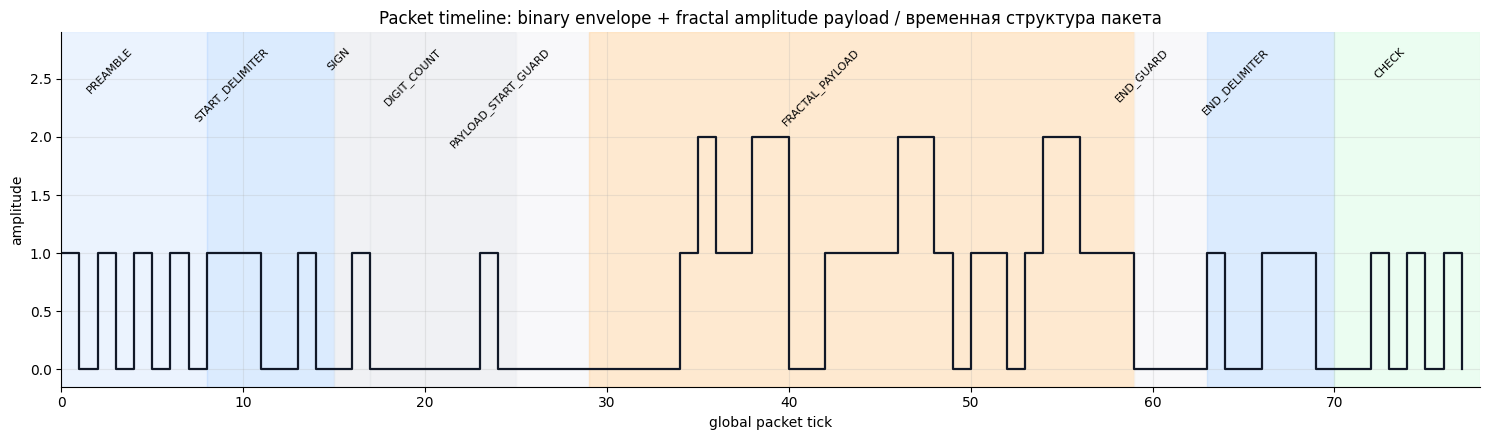

In [4]:
plot_packet_timeline(
    encoded,
    "Packet timeline: binary envelope + fractal amplitude payload / временная структура пакета",
);

## 3. Fractal Payload Cells / Ячейки фрактальной полезной нагрузки

**RU.** Внутри `FRACTAL_PAYLOAD` передается не binary representation числа. Число сначала раскладывается на mixed-radix digits `V_i`, а каждый `V_i` выбирает ячейку диагонального фрактального алфавита. Ячейка задает параметры генератора канала: период `P_i`, задержку старта `S_i` и ширину активной фазы.

Для числа `348` получаем два канала:

```text
348 -> digits (8, 17) -> cells [(P=4, S=3), (P=9, S=2)] -> A(t)
```

**EN.** `FRACTAL_PAYLOAD` does not transmit the binary representation of the number. The number is first decomposed into mixed-radix digits `V_i`, and each `V_i` selects a cell in the diagonal fractal alphabet. The selected cell defines channel generator parameters: period `P_i`, start delay `S_i`, and active phase width.

For the value `348`, the payload contains two channels:

```text
348 -> digits (8, 17) -> cells [(P=4, S=3), (P=9, S=2)] -> A(t)
```

In [5]:
payload_df = payload_cell_table(model, encoded.payload_cells)
payload_df

,channel_i,period_band,Base_i=sum(P),digit_V_i,period_index,P_i,legal_shift_range,S_i,active_width
0,0,"(2, 3, 4, 5, 6)",20,8,2,4,0..3,3,2
1,1,"(7, 8, 9, 10)",34,17,2,9,0..8,2,4


**Table Fields / Поля таблицы**

**RU.** `channel_i` - индекс канала/разряда. `period_band` - допустимые периоды этого канала. `Base_i=sum(P)` - основание разряда, равное числу допустимых диагональных ячеек. `digit_V_i` - digit числа в mixed-radix системе. `period_index` - индекс выбранной строки периода. `P_i` - период генератора. `legal_shift_range` - допустимые задержки для выбранного периода. `S_i` - выбранная задержка старта. `active_width` - длительность активной фазы внутри периода.

**EN.** `channel_i` is the channel/digit index. `period_band` lists allowed periods for this channel. `Base_i=sum(P)` is the digit radix, equal to the number of legal diagonal cells. `digit_V_i` is the mixed-radix digit. `period_index` is the selected period-row index. `P_i` is generator period. `legal_shift_range` lists legal start delays for the selected period. `S_i` is the selected start delay. `active_width` is active phase width inside the period.

## 4. Payload Signal Tracks / Сигналы каналов внутри payload

**RU.** Ниже показано, что происходит внутри `FRACTAL_PAYLOAD`. Каждый канал `C_i(t)` генерируется собственной ячейкой `(P_i, S_i)`. Передается не набор отдельных каналов, а их сумма `A(t)`. Именно эту амплитудную форму receiver затем декодирует обратно в cells и digits.

**EN.** The plot below shows what happens inside `FRACTAL_PAYLOAD`. Each channel `C_i(t)` is generated by its own cell `(P_i, S_i)`. The transmitted payload is not a bundle of separate channels, but their sum `A(t)`. The receiver decodes this amplitude form back into cells and digits.

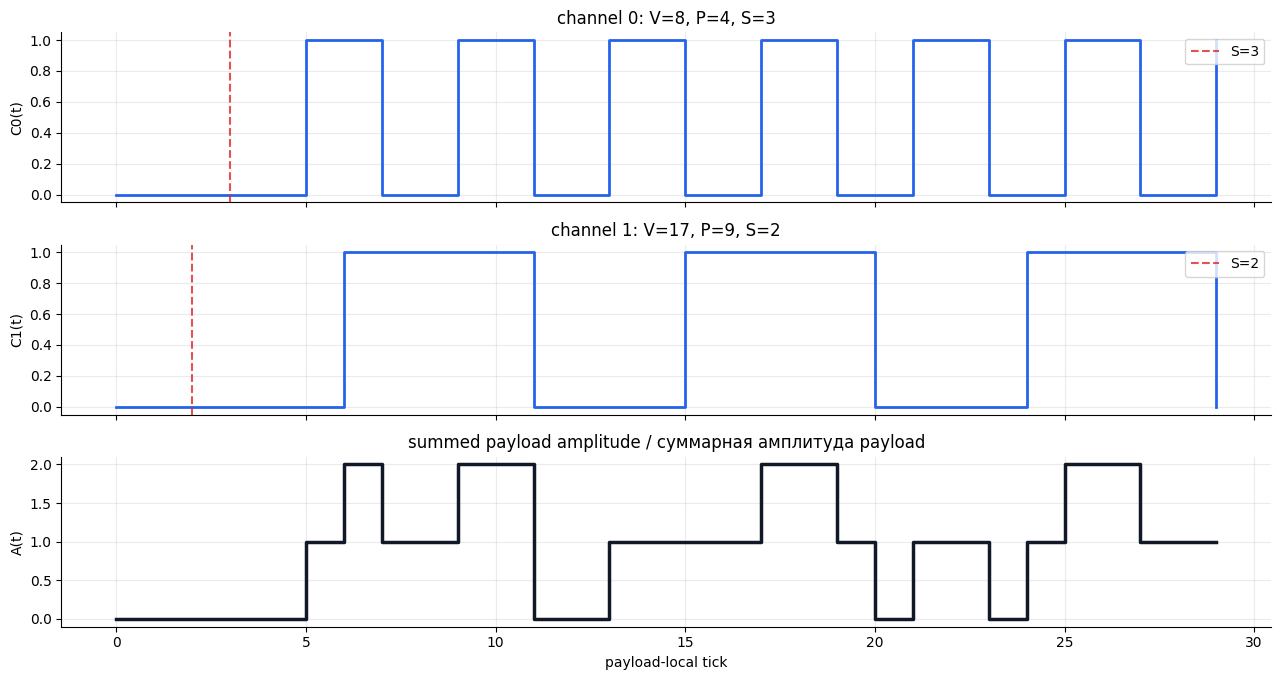

In [6]:
plot_payload_tracks(model, encoded);

## 5. Packet Samples / Дискретные отсчеты пакета

**RU.** В реализации пакет является последовательностью отсчетов `PacketSample`. Каждый отсчет имеет глобальный `tick`, имя текущего поля, общую амплитуду и отдельную `payload_amplitude`. Для service-полей `payload_amplitude=0`, потому что там передается бинарная управляющая информация. Для `FRACTAL_PAYLOAD` она совпадает с суммарным сигналом `A(t)`.

**EN.** In the implementation, a packet is a sequence of `PacketSample` values. Each sample has a global `tick`, current field name, total amplitude, and separate `payload_amplitude`. For service fields, `payload_amplitude=0` because they carry binary control information. For `FRACTAL_PAYLOAD`, it equals the summed signal `A(t)`.

In [7]:
packet_samples_table(encoded, limit=36)

,tick,field,total_amplitude,payload_amplitude
0,0,PREAMBLE,1.0,0.0
1,1,PREAMBLE,0.0,0.0
2,2,PREAMBLE,1.0,0.0
3,3,PREAMBLE,0.0,0.0
4,4,PREAMBLE,1.0,0.0
5,5,PREAMBLE,0.0,0.0
6,6,PREAMBLE,1.0,0.0
7,7,PREAMBLE,0.0,0.0
8,8,START_DELIMITER,1.0,0.0
9,9,START_DELIMITER,1.0,0.0


**Table Fields / Поля таблицы**

**RU.** `tick` - глобальный номер дискретного отсчета в пакете. `field` - поле, которому принадлежит отсчет. `total_amplitude` - фактический уровень, который видит receiver. `payload_amplitude` - вклад fractal payload; он равен нулю вне `FRACTAL_PAYLOAD`.

**EN.** `tick` is the global discrete sample index inside the packet. `field` is the owning packet field. `total_amplitude` is the level observed by the receiver. `payload_amplitude` is the fractal payload contribution; it is zero outside `FRACTAL_PAYLOAD`.

## 6. Receiver-Side Decode / Декодирование на стороне приемника

**RU.** Receiver работает последовательно. Сначала он переводит service-level samples в binary bits по threshold, затем ищет `PREAMBLE + START_DELIMITER`. После этого receiver читает `SIGN`, `DIGIT_COUNT`, guard, ищет окончание payload, декодирует `A(t)` и сравнивает checksum.

Технически checksum считается не по `S_i` и не по одному глобальному radix, а по recovered mixed-radix digits:

$$
CHECK = \left(\sum_i (i + 1) \cdot V_i\right) \bmod 256
$$

**EN.** The receiver works sequentially. First it converts service-level samples into binary bits using a threshold, then searches for `PREAMBLE + START_DELIMITER`. After that it reads `SIGN`, `DIGIT_COUNT`, the guard interval, searches for payload end, decodes `A(t)`, and compares the checksum.

Technically, the checksum is computed not from `S_i` and not from one global radix, but from recovered mixed-radix digits:

$$
CHECK = \left(\sum_i (i + 1) \cdot V_i\right) \bmod 256
$$

In [8]:
decoded = codec.decode(encoded.samples)

assert decoded.value == value
assert decoded.payload_digits == encoded.payload_digits
assert decoded.payload_cells == encoded.payload_cells
assert decoded.check_ok

decode_trace_table(codec, encoded, decoded)

,step,receiver_action,result
0,1,find PREAMBLE + START_DELIMITER,"sync_start=0, sync_bits=101010101110010"
1,2,read SIGN,sign=-1
2,3,read DIGIT_COUNT,digit_count=2
3,4,slice FRACTAL_PAYLOAD,"payload ticks [29, 59)"
4,5,decode payload A(t),"digits=(8, 17), absolute=348"
5,6,validate CHECK,"received=42, expected=42, ok=True"
6,7,restore signed value,value=-348


**Table Fields / Поля таблицы**

**RU.** `step` - номер шага receiver pipeline. `receiver_action` - действие декодера. `result` - результат после выполнения шага. Если любой из критических шагов не проходит, decoder выбрасывает `ValueError`, а packet не считается восстановленным.

**EN.** `step` is the receiver pipeline step number. `receiver_action` is the decoder operation. `result` is the state after that operation. If any critical step fails, the decoder raises `ValueError`, and the packet is not considered recovered.

In [9]:
decode_summary = pd.DataFrame([
    {"name": "decoded value", "value": decoded.value},
    {"name": "sign", "value": decoded.sign},
    {"name": "absolute payload", "value": decoded.absolute_value},
    {"name": "digit_count", "value": decoded.digit_count},
    {"name": "decoded digits", "value": decoded.payload_digits},
    {"name": "decoded cells", "value": [(cell.period_ticks, cell.shift_ticks) for cell in decoded.payload_cells]},
    {"name": "check value", "value": decoded.check_value},
    {"name": "expected check", "value": decoded.expected_check_value},
    {"name": "check_ok", "value": decoded.check_ok},
])

decode_summary

,name,value
0,decoded value,-348
1,sign,-1
2,absolute payload,348
3,digit_count,2
4,decoded digits,"(8, 17)"
5,decoded cells,"[(4, 3), (9, 2)]"
6,check value,42
7,expected check,42
8,check_ok,True


## 7. Error Detection / Обнаружение ошибок

**RU.** Проверим две типовые поломки. Если испортить `START_DELIMITER`, receiver теряет корректную точку входа в пакет. Если испортить `CHECK`, payload может быть декодирован, но recovered digits не проходят контрольную сумму.

Этот блок не моделирует шум канала полностью. Он показывает минимальный смысл service-полей: delimiter защищает структуру пакета, checksum защищает согласованность payload.

**EN.** We test two typical corruptions. If `START_DELIMITER` is corrupted, the receiver loses the valid packet entry point. If `CHECK` is corrupted, the payload may still be decoded, but recovered digits fail checksum validation.

This block is not a full channel-noise model. It shows the minimal purpose of service fields: delimiters protect packet structure, while checksum protects payload consistency.

In [10]:
corruption_df = pd.DataFrame([
    corruption_result(codec, encoded, "START_DELIMITER", offset=0),
    corruption_result(codec, encoded, "CHECK", offset=0),
])

corruption_df

,corrupted_field,corrupted_tick,decoder_result,message
0,START_DELIMITER,8,ValueError,PREAMBLE + START_DELIMITER not found
1,CHECK,70,ValueError,CHECK mismatch


**Table Fields / Поля таблицы**

**RU.** `corrupted_field` - поле, в котором был инвертирован один отсчет. `corrupted_tick` - глобальный tick испорченного отсчета. `decoder_result` - тип результата decoder. `message` - диагностическое сообщение, объясняющее, почему packet rejected.

**EN.** `corrupted_field` is the field where one sample was flipped. `corrupted_tick` is the global tick of the corrupted sample. `decoder_result` is the decoder result type. `message` is the diagnostic explanation for packet rejection.

## 8. Conclusions / Выводы

**RU.** `FractalSNNPacketCodec` добавляет транспортный слой поверх фрактального числа. Само число по-прежнему кодируется структурой `(V_i -> P_i, S_i -> C_i(t) -> A(t))`, но packet делает эту структуру пригодной для передачи по дискретному импульсно-амплитудному потоку.

Главные выводы:

- `PREAMBLE` и `START_DELIMITER` дают receiver точку синхронизации и начало frame.
- `SIGN` отделяет знак от fractal payload, поэтому payload кодирует модуль числа.
- `DIGIT_COUNT` критичен для mixed-radix payload: decoder должен знать, сколько каналов восстанавливать.
- `PAYLOAD_START_GUARD`, `END_GUARD` и `END_DELIMITER` отделяют амплитудный payload от бинарных service-полей.
- `CHECK` проверяет recovered mixed-radix digits, а не только raw waveform.

**EN.** `FractalSNNPacketCodec` adds a transport layer above the fractal number. The number is still encoded by the structure `(V_i -> P_i, S_i -> C_i(t) -> A(t))`, but the packet makes this structure usable for transmission through a discrete pulse-amplitude stream.

Main conclusions:

- `PREAMBLE` and `START_DELIMITER` give the receiver a synchronization point and frame start.
- `SIGN` separates sign from fractal payload, so the payload encodes the absolute value.
- `DIGIT_COUNT` is critical for mixed-radix payloads: the decoder must know how many channels to recover.
- `PAYLOAD_START_GUARD`, `END_GUARD`, and `END_DELIMITER` separate amplitude payload from binary service fields.
- `CHECK` validates recovered mixed-radix digits, not just the raw waveform.